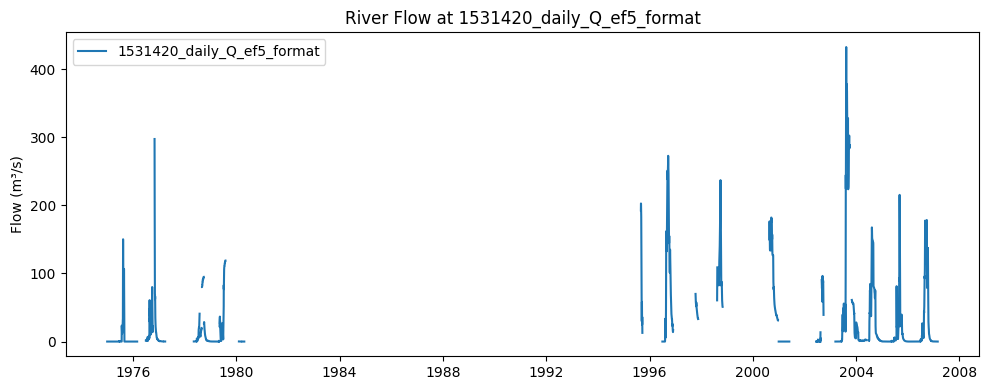

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

# ── Add or remove CSV files here ──────────────────────────────────────────────
csv_files = [
    r"X:\WMO_BF\AGRH\EF5WADomain-main\GHANA_domain\Results\1kmEF5CalibSteps\1531420_daily_Q_ef5_format.csv",
    # r"X:\WMO_BF\BF_Calibration\v2\highObsGauges\OBS\AMMA2050_RiverFlow_RimkietaNorth.csv",
    # r"X:\WMO_BF\BF_Calibration\v2\highObsGauges\OBS\AMMA2050_RiverFlow_RimkietaSouth.csv",
]
# ─────────────────────────────────────────────────────────────────────────────

dfs = []
for path in csv_files:
    df_tmp = pd.read_csv(path)
    df_tmp["date"] = pd.to_datetime(df_tmp["date"], format="%m/%d/%Y")
    # Use the filename (without extension) as the column name
    label = pd.Series(path).str.split(r"[\\/]").explode().iloc[-1].replace(".csv", "")
    # Rename whichever column isn't "date" to the label
    flow_col = [c for c in df_tmp.columns if c != "date"][0]
    df_tmp = df_tmp.rename(columns={flow_col: label})[["date", label]]
    dfs.append(df_tmp)

# Merge all DataFrames on date
df = dfs[0]
for d in dfs[1:]:
    df = pd.merge(df, d, on="date", how="outer")
df.sort_values("date", inplace=True)

gauge_cols = [c for c in df.columns if c != "date"]

# One subplot per gauge
fig, axes = plt.subplots(nrows=len(gauge_cols), ncols=1,
                         figsize=(10, 4 * len(gauge_cols)), sharex=True)

# Ensure axes is always iterable (handles the single-plot case)
if len(gauge_cols) == 1:
    axes = [axes]

for ax, col in zip(axes, gauge_cols):
    ax.plot(df["date"], df[col], label=col)
    ax.set_title(f"River Flow at {col}")
    ax.set_ylabel("Flow (m³/s)")
    ax.legend()

plt.tight_layout()
plt.show()
